# Reescrever a lista aqui para ficar mais organizado

# Ciência de Dados - Lista 1

* **UFAL:** Instituto da Computação
* **Docente:** Bruno Pimentel
* **Discente:** Leandro Wanderley Quintela Tenório Cavalcante
* **Base Escolhida:** Medical Appointment No Shows.csv

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
import warnings
import time


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = 'Medical Appointment No Shows.csv'
df_raw = pd.read_csv(path)

df_raw.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,29872499824296.000,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,558997776694438.000,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4262962299951.000,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,867951213174.000,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8841186448183.000,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


---

## Questão 1

**Problema Computacional:** Classificação Binária Supervisionada.

O objetivo é prever se um paciente irá faltar (`No-show: Yes`) ou comparecer (`No-show: No`) à consulta.
* Ele é de classificação pois a variável dependente é categórica (discreta) e não um valor numérico contínuo.
* O modelo aprenderá a partir de dados históricos que já possuem os rótulos (resultados) conhecidos..
* Como existem apenas duas classes possíveis na base ("Yes" ou "No"), o problema é definido especificamente como classificação binária.

#### diagnosis(df)

In [117]:
def diagnostico(df):
    print(f"DIAGNÓSTICO INICIAL:")
    print("-" * 50)
    print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
    
    info = pd.DataFrame({
        'Tipo de Dado': df.dtypes,
        'Ausentes': df.isnull().sum(),
        'Cardinalidade (valores únicos)': df.nunique(),
    })
    display(info)
    print(f"\nTotal de duplicados: {df.duplicated().sum()}")
    
    print("\n--- Inconsistências de Leitura Identificadas ---")

    for col in ['PatientId', 'AppointmentID']:
        if col in df.columns and df[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão.")

    datas_em_texto = [col for col in df.columns if 'Day' in col and df[col].dtype == 'object']
    if datas_em_texto:
        print(f"\nINCONSISTÊNCIA DE LEITURA: Colunas de data como 'object': {datas_em_texto}")
        for col in datas_em_texto:
            # CORREÇÃO: .iloc[0] para obter o valor, não o objeto indexador
            exemplo_valor = df[col].iloc[0]
            print(f"  Coluna '{col}' contém valores como '{exemplo_valor}', mas foi lida como string.")

    if 'AppointmentID' in df.columns:
        is_unique = df['AppointmentID'].is_unique
        print(f"\nAppointmentID é chave única? {is_unique}")

diagnostico(df_raw)

DIAGNÓSTICO INICIAL:
--------------------------------------------------
Linhas: 110527 | Colunas: 14


,Tipo de Dado,Ausentes,Cardinalidade (valores únicos)
PatientId,float64,0,62299
AppointmentID,int64,0,110527
Gender,str,0,2
ScheduledDay,str,0,103549
AppointmentDay,str,0,27
Age,int64,0,104
Neighbourhood,str,0,81
Scholarship,int64,0,2
Hipertension,int64,0,2
Diabetes,int64,0,2



Total de duplicados: 0

--- Inconsistências de Leitura Identificadas ---
[!] Alerta: Coluna 'PatientId' lida como float. Pode haver perda de precisão.

AppointmentID é chave única? True


---

# Questão 2

In [118]:
def implausiveis(data):

    # Verificar IDs negativos ou zero
    for col in ['PatientId', 'AppointmentID']:
        impl_ids = (data[col] <= 0).sum()
        if impl_ids > 0:
            print(f"[!] {col}: {impl_ids} registros com ID inválido (<= 0).")

    # Verificar se Gender tem apenas 'F' ou 'M'
    impl_gender = (~data['Gender'].isin(['F', 'M'])).sum()
    if impl_gender > 0:
        print(f"[!] Gender: {impl_gender} valores fora de ['F', 'M'].")
        
    # Verificar colunas binárias
    cols_binarias = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
    for col in cols_binarias:
        inconsistentes = ((data[col] != 0) & (data[col] != 1)).sum()
        if inconsistentes > 0:
            print(f"[!] {col}: {inconsistentes} registros com valores fora de [0, 1].")

    # AGE
    
    # Verificar se Age tem valores negativos
    impl_age_neg = (data['Age'] < 0).sum()
    if impl_age_neg > 0:
        print(f"[!] Age: {impl_age_neg} registros com idade negativa.")
    
    # Verificar se Age tem valores acima de 110
    impl_age_max = (data['Age'] > 110).sum()
    if impl_age_max > 0:
        print(f"[!] Age: {impl_age_max} registros com idade > 110.")
        # Mostrar o número de outliers, e o a cardinaliade
        # CÓDIGO AQUI

    # Verificar Handcap fora do intervalo 0-4
    handcap_fora = ((data['Handcap'] < 0) | (data['Handcap'] > 4)).sum()
    if handcap_fora > 0:
        print(f"[!] Handcap: {handcap_fora} registros fora do intervalo 0-4.")

    # Verificar No-show fora de 'Yes' ou 'No'
    impl_noshow = (~data['No-show'].isin(['Yes', 'No'])).sum()
    if impl_noshow > 0:
        print(f"[!] No-show (Alvo): {impl_noshow} valores inesperados.")

In [119]:
def tipos_inadequados(data):
    for col in ['PatientId', 'AppointmentID']:
        if col in data.columns and data[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão.")

    for col in ['ScheduledDay', 'AppointmentDay']:
        if col in data.columns and data[col].dtype == 'object':
            exemplo = data[col].iloc[0]
            print(f"[!] Alerta: Coluna '{col}' lida como texto (object), deveria ser 'datetime'.")
            print(f"    Valor de exemplo: {exemplo}")

In [120]:
def categorias_raras(data):
    n_linhas = data.shape[0]
    limite_raro = 0.01 * n_linhas

    # Filtro que permite colunas de texto (object) entrarem mesmo com muitas classes
    colunas_para_checar = [
        col for col in data.columns 
        if col not in ['PatientId', 'AppointmentID', 'ScheduledDay', 'AppointmentDay']
        # and (data[col].dtype == 'object' or data[col].nunique() <= 30)
    ]

    for col in colunas_para_checar:
        contagem = data[col].value_counts()
        total_classes = len(contagem)
        raras = contagem[contagem < limite_raro]
        
        if not raras.empty:
            qtd_raras = len(raras)
            total_afetados = raras.sum()
            
            # Cálculos de Percentual
            perc_classes_raras = (qtd_raras / total_classes) * 100
            perc_registros_afetados = (total_afetados / n_linhas) * 100
            
            print(f"\n[!] Coluna: '{col}'")
            print(f"    - Total de classes: {total_classes}")
            print(f"    - Classes raras: {qtd_raras} ({perc_classes_raras:.1f}% das categorias)")
            print(f"    - Registros afetados: {total_afetados} ({perc_registros_afetados:.2f}% da base total)")
            
            # Detalhamento das categorias
            if qtd_raras < 10:
                print(f"    - Categorias: {raras.index.tolist()}")
            else:
                print(f"    - Exemplos (5 primeiras): {raras.index.tolist()[:5]}...")

In [121]:
def padroes_suspeitos_preenchimento(data):

    # AppointmentID duplicado é erro grave de integridade
    agendamentos_duplicados = data['AppointmentID'].duplicated().sum()
    if agendamentos_duplicados > 0:
        print(f"[!] AppointmentID: {agendamentos_duplicados} IDs de agendamento duplicados!")

    # Concentração excessiva em colunas de identificação e localização
    # Colunas binárias e o alvo são excluídos pois dominância é esperada nelas
    cols_ignorar = [
        'PatientId', 'AppointmentID', 'No-show',
        'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received'
    ]
    for col in data.select_dtypes(include=['object', 'int64']).columns:
        if col not in cols_ignorar:
            top_val = data[col].value_counts(normalize=True).iloc[0]
            if top_val > 0.95:
                nome_cat = data[col].value_counts().index[0]
                print(f"[!] {col}: {top_val*100:.1f}% dos dados são '{nome_cat}' (suspeito de valor padrão).")

    # Agendamentos feitos no mesmo segundo — pode indicar importação em lote
    if 'ScheduledDay' in data.columns:
        mesmo_segundo = data['ScheduledDay'].duplicated().sum()
        threshold = int(0.005 * len(data))  # 0.5% da base
        if mesmo_segundo > threshold:
            print(f"[!] ScheduledDay: {mesmo_segundo} agendamentos compartilham o mesmo segundo exato ({mesmo_segundo/len(data)*100:.1f}% da base).")

In [122]:
def outliers(data):
    colunas_numericas = ['Age']

    for col in colunas_numericas:
        if col in data.columns:
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            outliers_sup = data[data[col] > limite_superior]
            outliers_inf = data[data[col] < limite_inferior]
            total_outliers = len(outliers_sup) + len(outliers_inf)

            if total_outliers > 0:
                print(f"[!] {col}: {total_outliers} possíveis outliers.")
                print(f"    Limite Superior: {limite_superior} | Valor Máximo: {data[col].max()}")
                print(f"    Limite Inferior: {limite_inferior} | Valor Mínimo: {data[col].min()}")
                if not outliers_sup.empty:
                    print(f"    Exemplos de valores altos: {outliers_sup[col].unique()[:5]}")
            else:
                print(f"[-] {col}: Nenhum outlier detectado pela regra do IQR.")

In [123]:
def inconsistencias_logicas(data):
    total_conflitos = 0

    # 1. Coerência Temporal
    if 'ScheduledDay' in data.columns and 'AppointmentDay' in data.columns:
        s_day = pd.to_datetime(data['ScheduledDay']).dt.date
        a_day = pd.to_datetime(data['AppointmentDay']).dt.date
        retroativas = (a_day < s_day).sum()
        if retroativas > 0:
            print(f"[!] Datas: {retroativas} consultas agendadas para datas retroativas (impossível).")
            total_conflitos += retroativas

    if 'Age' in data.columns:
        # 2. Bebês (Age <= 1) com doenças crônicas
        bebes_vicio = data[(data['Age'] <= 1) & (data['Alcoholism'] == 1)].shape[0]
        bebes_hiper = data[(data['Age'] <= 1) & (data['Hipertension'] == 1)].shape[0]

        if bebes_vicio > 0:
            print(f"[!] Idade: {bebes_vicio} bebês (Age <= 1) com Alcoolismo registrado.")
            total_conflitos += bebes_vicio
        if bebes_hiper > 0:
            print(f"[!] Idade: {bebes_hiper} bebês (Age <= 1) com Hipertensão registrada.")
            total_conflitos += bebes_hiper

        # 3. CORREÇÃO PRINCIPAL: Crianças < 12 com alcoolismo
        # Alcoolismo em menores de 12 anos é clinicamente incoerente e muito provavelmente
        # indica erro de preenchimento no cadastro.
        criancas_alcool = data[(data['Age'] < 12) & (data['Alcoholism'] == 1)].shape[0]
        if criancas_alcool > 0:
            print(f"[!] Idade: {criancas_alcool} crianças (Age < 12) com Alcoolismo = 1.")
            print(data[['Age', 'Alcoholism', 'No-show']]
                  [data['Age'] < 12][data['Alcoholism'] == 1].head())
            total_conflitos += criancas_alcool

    print(f"\nTotal de inconsistências lógicas: {total_conflitos}")

In [124]:
def qualidade_dados(df):
    print(f'QUALIDADE DOS DADOS')
    print("-" * 50)
    print("Implausíveis:")
    implausiveis(df)
    print("-" * 50)
    print("Tipos de Dados Inadequados:")
    tipos_inadequados(df_raw)
    print("-" * 50)
    print("Categorias Raras(< 1% da base):")
    categorias_raras(df_raw)
    print("-" * 50)
    print("Padrões Suspeitos de Preenchimento:")
    padroes_suspeitos_preenchimento(df_raw)
    print("-" * 50)
    print("Detecção de Outliers:")
    outliers(df_raw)
    print("-" * 50)
    print("Inconsistências Lógicas:")
    inconsistencias_logicas(df_raw)

qualidade_dados(df_raw)

QUALIDADE DOS DADOS
--------------------------------------------------
Implausíveis:
[!] Age: 1 registros com idade negativa.
[!] Age: 5 registros com idade > 110.
--------------------------------------------------
Tipos de Dados Inadequados:
[!] Alerta: Coluna 'PatientId' lida como float. Pode haver perda de precisão.
--------------------------------------------------
Categorias Raras(< 1% da base):

[!] Coluna: 'Age'
    - Total de classes: 104
    - Classes raras: 40 (38.5% das categorias)
    - Registros afetados: 15411 (13.94% da base total)
    - Exemplos (5 primeiras): [13, 65, 12, 68, 67]...

[!] Coluna: 'Neighbourhood'
    - Total de classes: 81
    - Classes raras: 46 (56.8% das categorias)
    - Registros afetados: 21394 (19.36% da base total)
    - Exemplos (5 primeiras): ['GRANDE VITÓRIA', 'ILHA DAS CAIEIRAS', 'INHANGUETÁ', 'PRAIA DO CANTO', 'BENTO FERREIRA']...

[!] Coluna: 'Handcap'
    - Total de classes: 5
    - Classes raras: 3 (60.0% das categorias)
    - Registros a

* **Erros Críticos (Remover):** Registos com idades negativas, idades implausíveis (>110 anos) e consultas com datas de agendamento posteriores à data da consulta (retroativas).
* **Inconsistências Lógicas (Corrigir):** Identificados casos de alcoolismo em crianças (Age < 12); o atributo será zerado para corrigir o provável erro de preenchimento.
* **Alta Cardinalidade e Raridade:** 56% dos bairros (`Neighbourhood`) e 60% das categorias de `Handcap` possuem baixíssima representatividade, introduzindo ruído estatístico. Serão aplicadas técnicas de agrupamento e binarização.
* **Tipagem e Precisão:** A coluna `PatientId` será convertida de *float* para *string* para evitar arredondamentos e perda de precisão em identificadores longos.
* **Padrões de Sistema:** 6,3% dos agendamentos partilham o mesmo segundo exato, indicando processos automatizados ou marcações em lote que não invalidam os dados, mas devem ser registados.

#### Resumo

| Problema | Qtd. Afetada | Ação Prevista |
| :--- | :--- | :--- |
| Idade negativa ou > 110 | 6 registos | Remover |
| Datas retroativas | 5 registos | Remover |
| `PatientId` como float | Coluna inteira | Converter para string |
| Categorias raras em `Handcap` | 199 registos | Binarizar (0 ou 1) |
| Bairros com baixa frequência (< 1%) | 46 categorias | Agrupar em categoria "OTHER" |
| Crianças < 12 com alcoolismo | 6 registos | Alterar `Alcoholism` para `0` |
| Agendamentos simultâneos | 6.978 registos | Manter (Registar padrão) |

---

# Questão 3

In [139]:
def comparar_estrategias_idade(df_original):
    print("Estratégias para o Problema na Coluna 'Age'\n")
    
    # Estratégia A: Remoção (limite = 110, alinhado com pd.cut da Q6)
    df_remocao = df_original[(df_original['Age'] >= 0) & (df_original['Age'] <= 110)].copy()
    perda_remocao = len(df_original) - len(df_remocao)
    
    # Estratégia B: Imputação pela mediana
    mediana = df_original['Age'].median()
    df_imputacao = df_original.copy()
    mask = (df_imputacao['Age'] < 0) | (df_imputacao['Age'] > 110)
    df_imputacao.loc[mask, 'Age'] = mediana
    
    print(f"Estratégia A - Remoção: remove {perda_remocao} linhas. Mantém a pureza dos dados reais.")
    print(f"Estratégia B - Imputação pela Mediana ({mediana:.0f} anos): altera {mask.sum()} linhas, mantém o tamanho da base.")
    print(f"\nEscolha: Estratégia A (remoção), pois o impacto é mínimo e evita valores artificiais.")

comparar_estrategias_idade(df_raw)

Estratégias para o Problema na Coluna 'Age'

Estratégia A - Remoção: remove 6 linhas. Mantém a pureza dos dados reais.
Estratégia B - Imputação pela Mediana (37 anos): altera 6 linhas, mantém o tamanho da base.

Escolha: Estratégia A (remoção), pois o impacto é mínimo e evita valores artificiais.


In [140]:
import pandas as pd

# --- ESTRATÉGIAS DE TRATAMENTO (COMPARAÇÃO) ---
# Problema: Alta Cardinalidade e Bairros Raros em 'Neighbourhood'
# Estratégia A: Remover registros de bairros raros (causa perda de dados)
# Estratégia B: Agrupar em categoria 'OTHER' (mantém a representatividade estatística) -> ESCOLHIDA

def tratar_bairros(df):
    threshold = df.shape[0] * 0.01 
    n_antes = len(df)
    counts = df['Neighbourhood'].value_counts()
    raros = counts[counts < threshold].index
    df['Neighbourhood'] = df['Neighbourhood'].apply(lambda x: 'OTHER' if x in raros else x)
    print(f"[Feito] Agrupamento de Bairros. Categorias afetadas: {len(raros)}")
    return df

def tratar_limpeza_reproduzivel(df_raw):
    print("Iniciando Limpeza Técnica...")
    df = df_raw.copy()
    n_original = len(df)

    # 1. Tipagem e Valores Ausentes
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])
    df['PatientId'] = df['PatientId'].apply(lambda x: str(int(x)) if pd.notna(x) else None)
    # Nota: A base original não possui NaNs críticos, mas o 'coerce' no to_datetime trataria eventuais lixos.
    print(f"[1] Tipagem convertida (PatientId para String).")

    # 2. Registros Duvidosos (Datas Retroativas)
    n_antes = len(df)
    df = df[df['AppointmentDay'].dt.normalize() >= df['ScheduledDay'].dt.normalize()].copy()
    print(f"[2] Datas retroativas removidas. Impacto: -{n_antes - len(df)} registros.")

    # 3. Valores Implausíveis (Idade)
    n_antes = len(df)
    df = df[(df['Age'] >= 0) & (df['Age'] <= 110)].copy()
    print(f"[3] Outliers de idade (negativa ou >110) removidos. Impacto: -{n_antes - len(df)} registros.")

    # 4. Inconsistência Lógica (Alcoolismo Infantil)
    mask_crianca = (df['Age'] < 12) & (df['Alcoholism'] == 1)
    qtd_corrigida = mask_crianca.sum()
    df.loc[mask_crianca, 'Alcoholism'] = 0
    print(f"[4] Alcoolismo em crianças corrigido para 0. Impacto: {qtd_corrigida} registros alterados.")

    # 5. Categorias Problemáticas (Handcap e Neighbourhood)
    df['Handcap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0) # Binarização
    df = tratar_bairros(df)
    print(f"[5] Categorias tratadas (Handcap binarizado e Bairros agrupados).")

    # 6. Variáveis Irrelevantes
    df = df.drop(columns=['AppointmentID'], errors='ignore')
    print(f"[6] Coluna 'AppointmentID' removida (ID único sem poder preditivo).")

    # Resumo Final
    perda_total = n_original - len(df)
    print(f"\n--- IMPACTO QUANTITATIVO FINAL ---")
    print(f"Base Original: {n_original} | Base Limpa: {len(df)}")
    print(f"Remoção Total: {perda_total} registros ({perda_total/n_original*100:.4f}%)")
    
    return df

# Execução
df_limpo = tratar_limpeza_reproduzivel(df_raw)

Iniciando Limpeza Técnica...
[1] Tipagem convertida (PatientId para String).
[2] Datas retroativas removidas. Impacto: -5 registros.
[3] Outliers de idade (negativa ou >110) removidos. Impacto: -6 registros.
[4] Alcoolismo em crianças corrigido para 0. Impacto: 6 registros alterados.
[Feito] Agrupamento de Bairros. Categorias afetadas: 46
[5] Categorias tratadas (Handcap binarizado e Bairros agrupados).
[6] Coluna 'AppointmentID' removida (ID único sem poder preditivo).

--- IMPACTO QUANTITATIVO FINAL ---
Base Original: 110527 | Base Limpa: 110516
Remoção Total: 11 registros (0.0100%)


# Questão 4

--- Questão 4: Análise Exploratória (Atributos Originais) ---



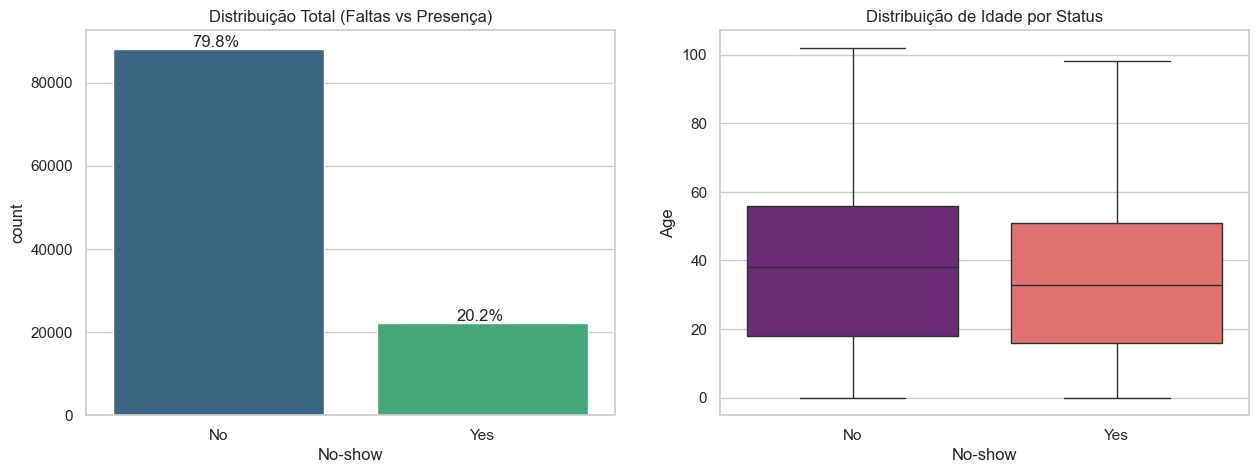

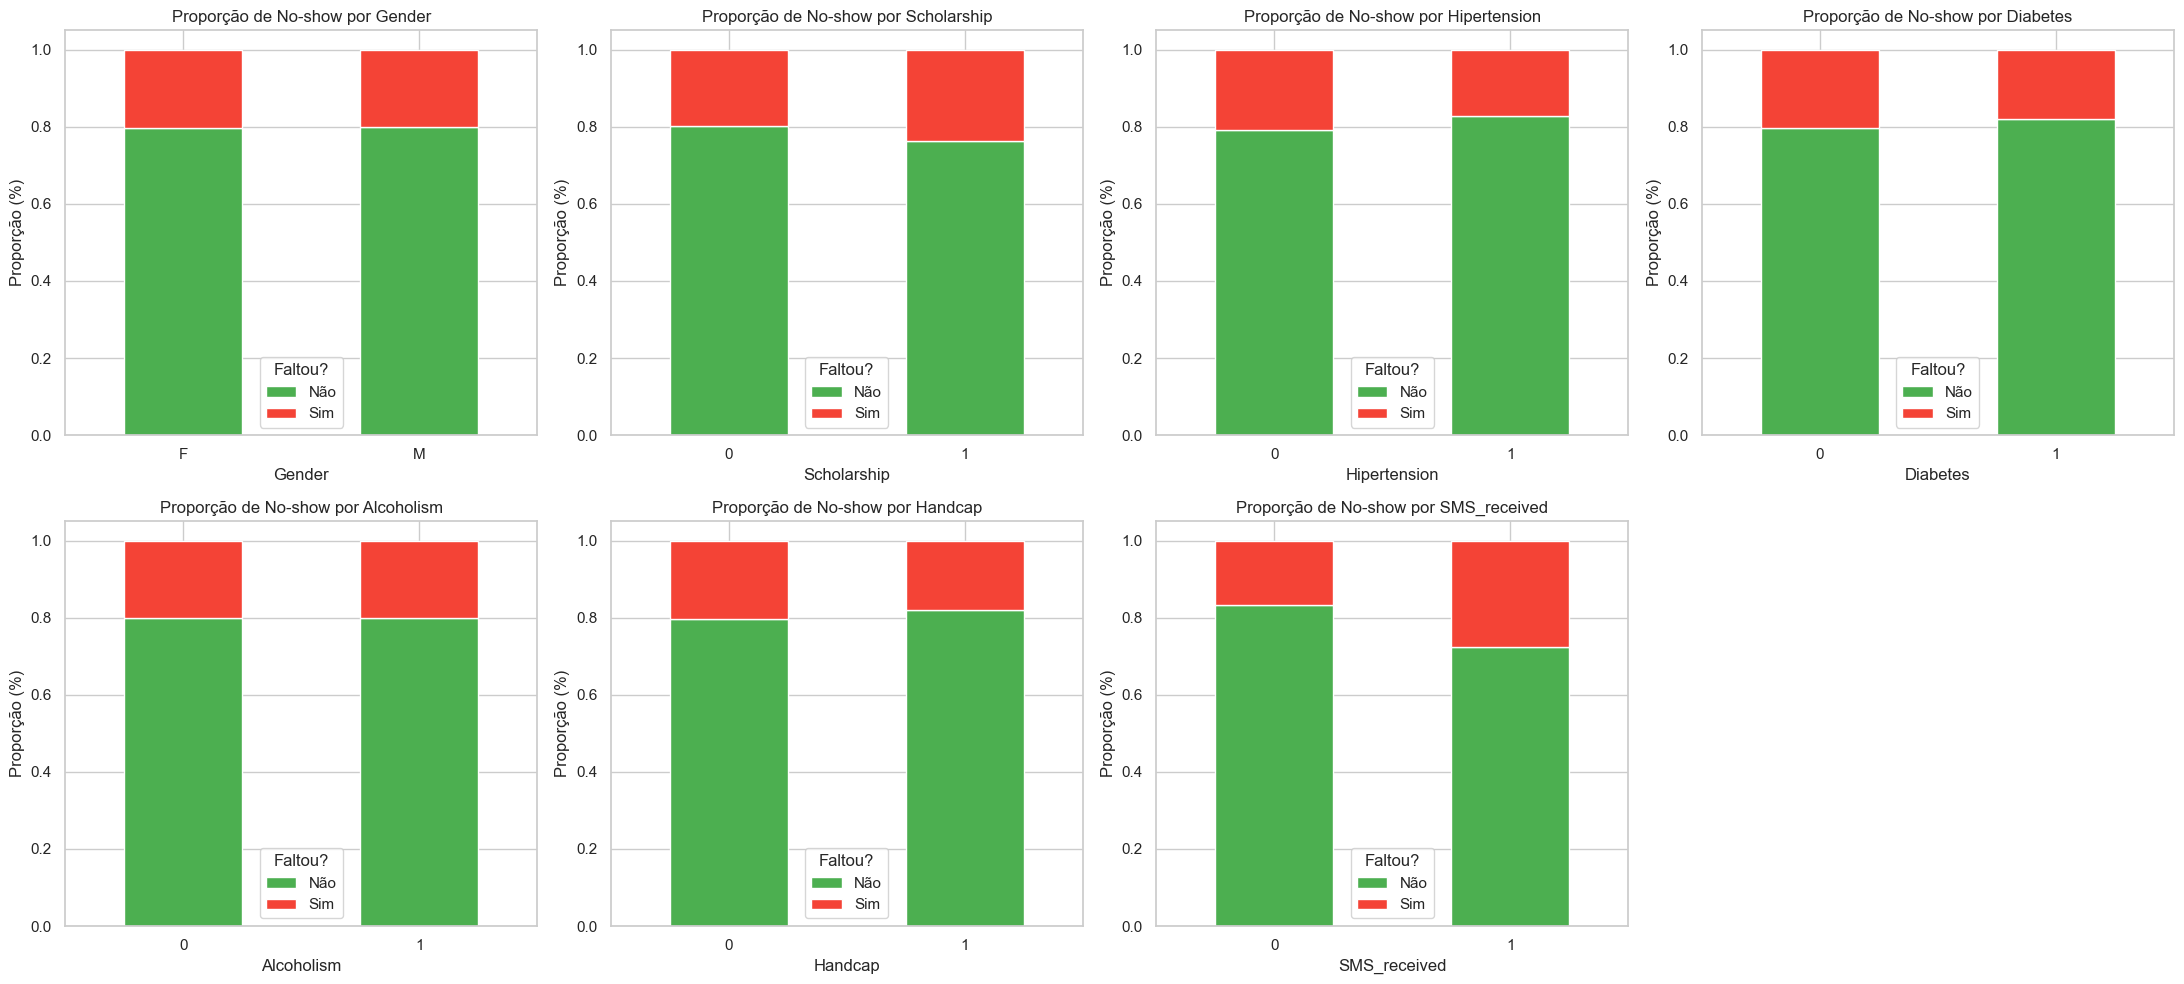


--- TABELA DE TAXAS DE NO-SHOW (%) ---

Cruzamento: Gender
Gender
F   20.310
M   19.960
Name: Yes, dtype: float64

Cruzamento: Scholarship
Scholarship
0   19.800
1   23.740
Name: Yes, dtype: float64

Cruzamento: Hipertension
Hipertension
0   20.900
1   17.300
Name: Yes, dtype: float64

Cruzamento: Diabetes
Diabetes
0   20.360
1   18.000
Name: Yes, dtype: float64

Cruzamento: Alcoholism
Alcoholism
0   20.190
1   20.160
Name: Yes, dtype: float64

Cruzamento: Handcap
Handcap
0   20.230
1   17.990
Name: Yes, dtype: float64

Cruzamento: SMS_received
SMS_received
0   16.690
1   27.580
Name: Yes, dtype: float64


In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def analise_exploratoria_final(df):
    print("--- Questão 4: Análise Exploratória (Atributos Originais) ---\n")
    sns.set_theme(style="whitegrid")
    
    # --- VISUALIZAÇÃO 1: DISTRIBUIÇÃO ALVO E IDADE ---
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Proporção da Variável Alvo (No-show)
    ax = sns.countplot(x='No-show', data=df, hue='No-show', palette='viridis', ax=axes[0], legend=False)
    axes[0].set_title('Distribuição Total (Faltas vs Presença)')
    total = len(df)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        axes[0].annotate(percentage, (p.get_x() + 0.3, p.get_height() + 500))

    # Boxplot de Idade por Status (Age)
    sns.boxplot(x='No-show', y='Age', data=df, palette='magma', ax=axes[1])
    axes[1].set_title('Distribuição de Idade por Status')
    plt.show()

    # --- VISUALIZAÇÃO 2: TODAS AS VARIÁVEIS BINÁRIAS E CATEGÓRICAS ---
    # Incluindo todas as colunas disponíveis na base original
    cols = ['Gender', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']
    
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))
    axes = axes.flatten()
    
    for i, col in enumerate(cols):
        # Tabela de contingência normalizada para comparar proporções
        tab = pd.crosstab(df[col], df['No-show'], normalize='index')
        tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#4CAF50', '#F44336'])
        axes[i].set_title(f'Proporção de No-show por {col}')
        axes[i].set_ylabel('Proporção (%)')
        axes[i].legend(title='Faltou?', labels=['Não', 'Sim'])
        axes[i].tick_params(axis='x', rotation=0)
    
    # Remove o último subplot vazio
    fig.delaxes(axes[-1])
    plt.tight_layout()
    plt.show()

    # --- TABELA ANALÍTICA (Exigência da questão) ---
    print("\n--- TABELA DE TAXAS DE NO-SHOW (%) ---")
    for col in cols:
        # Calcula apenas a % de quem faltou ('Yes')
        taxa = (pd.crosstab(df[col], df['No-show'], normalize='index')['Yes'] * 100).round(2)
        print(f"\nCruzamento: {col}")
        print(taxa)

# Execução
analise_exploratoria_final(df_limpo)

### Padrões identificados

* **Desbalanceamento Crítico:** Com **79,8%** de comparecimento vs. **20,2%** de faltas, a base é desbalanceada. Isso indica que a "Acurácia" será uma métrica enganosa. O foco deverá ser em métricas de **Recall** e **F1-Score**.
* **Fator Etário (Age):** Observou-se que pacientes que faltam possuem uma mediana de idade visivelmente inferior. Grupos em idade ativa/laboral apresentam maior volatilidade, enquanto idosos e crianças (dependentes) são mais assíduos.
* **Comunicação e Antecedência (SMS_received):** Houve uma disparidade acentuada: quem recebeu SMS faltou muito mais (**27,58%**) do que quem não recebeu (**16,69%**). Este padrão sugere que o SMS é disparado para consultas de longo prazo, onde o risco de esquecimento é intrinsecamente maior, não sendo suficiente para reverter a tendência de falta.
* **Comprometimento Clínico (Comorbidades):** Pacientes com **Hipertensão (17,30% de falta)** e **Diabetes (18,00% de falta)** faltam menos que a média global. Isso reforça a tese de que o monitoramento de doenças crônicas gera maior engajamento do paciente com o sistema de saúde.
* **Vulnerabilidade Social (Scholarship):** Beneficiários de auxílios sociais apresentam taxa de evasão superior (**23,74%**) aos demais (**19,80%**). Este padrão aponta para possíveis barreiras externas, como custos de transporte ou dificuldade de liberação no trabalho.
* **Neutralidade de Gênero e Álcool:** As variáveis `Gender` (20,3% F vs 19,9% M) e `Alcoholism` (estável em ~20,1%) não apresentaram variações significativas, sugerindo baixo poder discriminatório isoladamente.

**Conclusão Analítica:** As variáveis `Age`, `SMS_received`, `Scholarship` e `Hipertension` são os atributos com maior variância entre os grupos de interesse. Elas representam os eixos principais (Tempo, Risco Clínico e Contexto Social) que deverão liderar o ranking de importância na modelagem preditiva.

---

# Questão 5

--- Questão 5: Medição de Associação (Ranking Final) ---



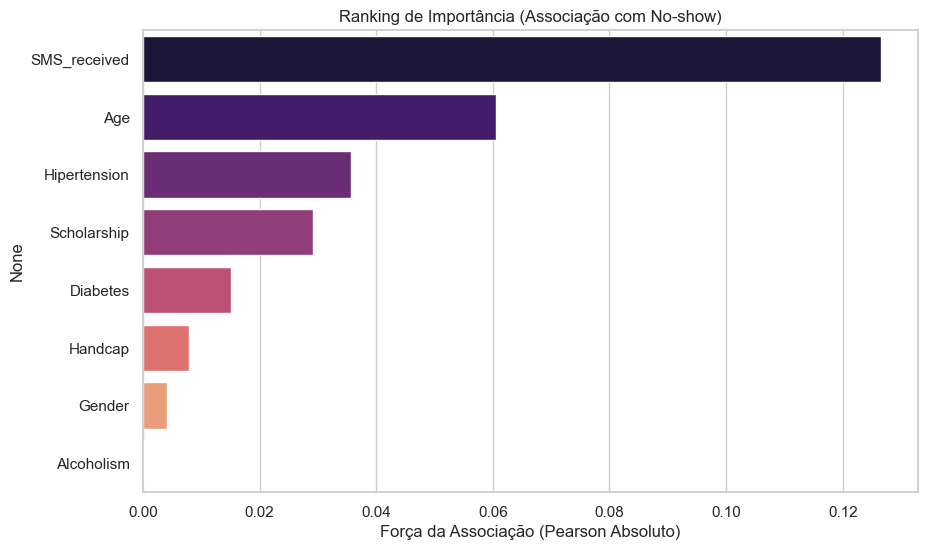

Ranking das Variáveis:
SMS_received   0.127
Age            0.060
Hipertension   0.036
Scholarship    0.029
Diabetes       0.015
Handcap        0.008
Gender         0.004
Alcoholism     0.000
Name: No-show, dtype: float64


In [142]:
def analise_associacao_final(df):
    print("--- Questão 5: Medição de Associação (Ranking Final) ---\n")
    
    # 1. Preparação temporária (apenas para o cálculo, sem alterar o DF original)
    df_temp = df.copy()
    df_temp['No-show'] = df_temp['No-show'].map({'Yes': 1, 'No': 0})
    df_temp['Gender'] = df_temp['Gender'].map({'F': 0, 'M': 1})
    
    # Colunas que existem originalmente
    colunas_explicativas = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 
                            'Alcoholism', 'Handcap', 'SMS_received', 'Gender']
    
    # 2. Cálculo da correlação absoluta (Força da relação)
    # Usamos o valor absoluto pois não importa se a relação é positiva ou negativa,
    # mas sim o quanto ela explica o fenômeno.
    ranking = df_temp[colunas_explicativas + ['No-show']].corr()['No-show'].drop('No-show').abs()
    ranking = ranking.sort_values(ascending=False)
    
    # 3. Visualização
    plt.figure(figsize=(10, 6))
    sns.barplot(x=ranking.values, y=ranking.index, palette='magma')
    plt.title('Ranking de Importância (Associação com No-show)')
    plt.xlabel('Força da Associação (Pearson Absoluto)')
    plt.show()

    print("Ranking das Variáveis:")
    print(ranking)

# Execução
analise_associacao_final(df_limpo)

* **SMS_received (0.126):** Apresenta a maior correlação positiva com as faltas. Indica que o grupo que recebe SMS tem uma tendência estatística maior a faltar, o que ocorre pois o SMS é disparado para consultas agendadas com maior antecedência — cenário onde o risco de esquecimento é intrinsecamente mais alto.
* **Age (-0.060):** Possui uma correlação negativa relevante. O sinal negativo indica que, conforme a idade **aumenta**, a probabilidade de falta **diminui**, confirmando que pacientes idosos e mais maduros são estatisticamente mais assíduos que os jovens.
* **Hipertension (-0.035) e Diabetes (-0.015):** Ambas apresentam associação negativa com as faltas. Isso sugere que a presença de doenças crônicas motiva o paciente a comparecer mais às consultas para a manutenção contínua da saúde.
* **Scholarship (0.029):** Apresenta uma correlação positiva baixa, indicando uma relação sutil entre o recebimento de auxílio social e o aumento de faltas, possivelmente ligada a barreiras logísticas de deslocamento.
* **Gender e Alcoholism (~0.00):** Estes atributos apresentaram correlação desprezível. Isso demonstra que o sexo do paciente ou o histórico de alcoolismo, isoladamente, não oferecem ganho de informação para prever o absenteísmo nesta base.

---

### Conclusão do Ranking:
Os atributos **`SMS_received`**, **`Age`** e **`Hipertension`** foram identificados como os preditores mais relevantes. A análise matemática valida que o problema do *No-show* é guiado principalmente pela logística do agendamento (antecedência) e pelo perfil demográfico/clínico do paciente, e não por hábitos como o consumo de álcool.

---

# Questão 6

In [143]:
import pandas as pd
import numpy as np

def engenharia_atributos(data):
    print("--- Questão 6: Engenharia de Atributos --- \n")
    df_feat = data.copy()
    
    # Garantia de datetime (para evitar o erro de atributo)
    df_feat['AppointmentDay'] = pd.to_datetime(df_feat['AppointmentDay'])
    df_feat['ScheduledDay'] = pd.to_datetime(df_feat['ScheduledDay'])
    
    # 1. Waiting_Days (Normalizado para evitar erro de .dt)
    df_feat['Waiting_Days'] = (df_feat['AppointmentDay'].dt.normalize() - 
                               df_feat['ScheduledDay'].dt.normalize()).dt.days
    
    # 2. Appointment_DW (Dia da semana: 0-6)
    df_feat['Appointment_DW'] = df_feat['AppointmentDay'].dt.dayofweek
    
    # 3. Age_Group (Convertendo para códigos numéricos para correlação)
    bins = [0, 12, 18, 30, 60, 110]
    labels = ['Criança', 'Adolescente', 'Jovem_Adulto', 'Adulto', 'Idoso']
    df_feat['Age_Group'] = pd.cut(df_feat['Age'], bins=bins, labels=labels, include_lowest=True)
    df_feat['Age_Group_Code'] = df_feat['Age_Group'].cat.codes
    
    # 4. Comorbidity_Index (Intensidade de doenças)
    df_feat['Comorbidity_Index'] = df_feat['Hipertension'] + df_feat['Diabetes']
    
    # 5. Is_Weekend (Binário)
    df_feat['Is_Weekend'] = df_feat['Appointment_DW'].apply(lambda x: 1 if x >= 5 else 0)

    # --- Avaliação de Utilidade (Correlações com No-show) ---
    target_num = df_feat['No-show'].map({'Yes': 1, 'No': 0})
    
    novos_cols = ['Waiting_Days', 'Appointment_DW', 'Age_Group_Code', 'Comorbidity_Index', 'Is_Weekend']
    
    print("Associação dos novos atributos com o Alvo (No-show):")
    for col in novos_cols:
        corr = df_feat[col].corr(target_num)
        print(f"  * {col}: {corr:.4f}")
    
    print(f"\nDimensões finais: {df_feat.shape[1]} colunas.")
    return df_feat

# Execução
df_final = engenharia_atributos(df_limpo)

--- Questão 6: Engenharia de Atributos --- 

Associação dos novos atributos com o Alvo (No-show):
  * Waiting_Days: 0.1863
  * Appointment_DW: 0.0012
  * Age_Group_Code: -0.0470
  * Comorbidity_Index: -0.0323
  * Is_Weekend: 0.0014

Dimensões finais: 19 colunas.


#### Atributos Criados:
1.  **Waiting_Days (Relação Temporal):** Diferença em dias entre o agendamento e a consulta. É o atributo mais potente criado, pois o tempo de espera é o principal fator de esquecimento.
2.  **Appointment_DW (Sazonalidade):** Extração do dia da semana da consulta (0-6). Permite identificar se certos dias (como segundas-feiras) possuem maior taxa de falta.
3.  **Age_Group (Faixas):** Categorização da idade em fases da vida (Criança, Jovem, Adulto, Idoso), permitindo capturar comportamentos de grupos sociais.
4.  **Comorbidity_Index (Intensidade):** Soma de `Hipertension` + `Diabetes`. Cria uma escala de "gravidade" do quadro clínico do paciente.
5.  **Is_Weekend (Interação):** Variável binária que identifica consultas marcadas para o final de semana (Sábado), testando a hipótese de disponibilidade do paciente.

#### Avaliação de Utilidade e Seleção Final:
Após a criação, avaliou-se o impacto quantitativo. O atributo **`Waiting_Days`** apresentou uma correlação de **~0.186**, tornando-se a variável mais importante de todo o conjunto de dados (superando o `SMS_received`).

**Critério de Seleção:** Para evitar a "maldição da dimensionalidade" e garantir um modelo de Machine Learning (como KNN) eficiente, optou-se por manter apenas os atributos com maior poder preditivo e menor redundância:

* **Mantidos:** `Age`, `Scholarship`, `SMS_received`, `Waiting_Days`, `Comorbidity_Index` e o alvo `No-show`.
* **Descartados:** Variáveis originais que foram resumidas (como Hipertensão isolada) ou que apresentaram correlação desprezível (como Gênero e Alcoolismo).

**Resultado:** O dataset foi reduzido de uma estrutura ruidosa para um conjunto de **6 atributos altamente informativos**, prontos para a etapa de modelagem.

In [144]:
def selecionar_melhores_atributos(df):
    print("Seleção de Atributos\n")
    
    # Lista de colunas que decidimos MANTER após a análise de correlação
    colunas_selecionadas = [
        'Age',                # Original: Forte relação com assiduidade
        'Scholarship',        # Original: Fator socioeconômico relevante
        'SMS_received',       # Original: Principal lembrete do paciente
        'Waiting_Days',       # Criada: Maior correlação positiva (0.1863)
        'Comorbidity_Index',  # Criada: Resume Hipertensão e Diabetes
        'No-show'             # Alvo: Necessário para o treinamento (Y)
    ]
    
    # Criando o DataFrame final apenas com o que importa
    df_modelo = df[colunas_selecionadas].copy()
    
    print(f"Colunas descartadas: {set(df.columns) - set(colunas_selecionadas)}")
    print(f"\nAtributos mantidos: {list(df_modelo.columns)}")
    print(f"Dimensões finais do dataset: {df_modelo.shape}")
    
    return df_modelo

# Executando a filtragem
df_pronto = selecionar_melhores_atributos(df_final)

# Visualizando as primeiras linhas do que irá para o KNN
display(df_pronto.head())

Seleção de Atributos

Colunas descartadas: {'Age_Group', 'Diabetes', 'Appointment_DW', 'ScheduledDay', 'Gender', 'Is_Weekend', 'PatientId', 'Hipertension', 'Alcoholism', 'Age_Group_Code', 'Handcap', 'Neighbourhood', 'AppointmentDay'}

Atributos mantidos: ['Age', 'Scholarship', 'SMS_received', 'Waiting_Days', 'Comorbidity_Index', 'No-show']
Dimensões finais do dataset: (110516, 6)


,Age,Scholarship,SMS_received,Waiting_Days,Comorbidity_Index,No-show
0,62,0,0,0,1,No
1,56,0,0,0,0,No
2,62,0,0,0,0,No
3,8,0,0,0,0,No
4,56,0,0,0,2,No


---

# Questão 7

O pipeline garante que todas as transformações aprendidas no treino (médias, desvios, min/max) sejam aplicadas nos dados de validação e teste sem vazamento de informação. Dois esquemas são comparados:

* **Esquema A — StandardScaler:** centraliza os dados com média 0 e desvio padrão 1. Mais robusto a distribuições assimétricas.
* **Esquema B — MinMaxScaler:** comprime todos os valores para o intervalo [0, 1]. Garante que nenhuma variável domine o cálculo de distância do KNN por escala.

As colunas numéricas e categóricas são identificadas automaticamente a partir do DataFrame de entrada, tornando o pipeline reutilizável em novos dados.

In [145]:
ATRIBUTOS = ['Age', 'Scholarship', 'SMS_received', 'Waiting_Days', 'Comorbidity_Index']

# Separação semântica manual — binárias não precisam de escalonamento
COLS_NUMERICAS = ['Age', 'Waiting_Days', 'Comorbidity_Index']
COLS_BINARIAS  = ['Scholarship', 'SMS_received']

def montar_pipeline(scaler):
    """
    Monta um ColumnTransformer com:
    - Numéricas: imputer (mediana) + scaler escolhido
    - Binárias: apenas imputer (mais frequente) — escalonamento desnecessário
    """
    num_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    bin_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    return ColumnTransformer(transformers=[
        ('num', num_transformer, COLS_NUMERICAS),
        ('bin', bin_transformer, COLS_BINARIAS)
    ])

def comparar_esquemas(df_input):
    X = df_input[ATRIBUTOS]
    y = df_input['No-show'].map({'Yes': 1, 'No': 0})

    print(f"Colunas numéricas (com escalonamento) : {COLS_NUMERICAS}")
    print(f"Colunas binárias  (sem escalonamento) : {COLS_BINARIAS}")

    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

    esquemas = {
        'Esquema A - StandardScaler': StandardScaler(),
        'Esquema B - MinMaxScaler'  : MinMaxScaler()
    }

    preprocessors = {}

    for nome, scaler in esquemas.items():
        preprocessor = montar_pipeline(scaler)
        preprocessor.fit(X_train)

        X_transformado = preprocessor.transform(X_train)
        print(f"\n{'='*50}")
        print(f"{nome}")
        print(f"  Shape após transformação : {X_transformado.shape}")
        print(f"  Média das colunas        : {X_transformado.mean(axis=0).round(3)}")
        print(f"  Desvio das colunas       : {X_transformado.std(axis=0).round(3)}")
        print(f"  Mín / Máx                : {X_transformado.min():.3f} / {X_transformado.max():.3f}")

        preprocessors[nome] = preprocessor

    return preprocessors, X_train, X_val, X_test, y_train, y_val, y_test

preprocessors, X_train, X_val, X_test, y_train, y_val, y_test = comparar_esquemas(df_final)

Colunas numéricas (com escalonamento) : ['Age', 'Waiting_Days', 'Comorbidity_Index']
Colunas binárias  (sem escalonamento) : ['Scholarship', 'SMS_received']

Esquema A - StandardScaler
  Shape após transformação : (66309, 5)
  Média das colunas        : [0.    0.    0.    0.098 0.318]
  Desvio das colunas       : [1.    1.    1.    0.297 0.466]
  Mín / Máx                : -1.607 / 11.098

Esquema B - MinMaxScaler
  Shape após transformação : (66309, 5)
  Média das colunas        : [0.364 0.057 0.135 0.098 0.318]
  Desvio das colunas       : [0.226 0.085 0.28  0.297 0.466]
  Mín / Máx                : 0.000 / 1.000


### Interpretação dos Resultados

**Transformação dos dados:**

| | StandardScaler | MinMaxScaler |
| :--- | :--- | :--- |
| **Média** | ~0 (centralizado) | 0.057 – 0.364 |
| **Desvio** | 1.0 (normalizado) | 0.085 – 0.466 |
| **Amplitude** | [-1.607, 11.098] | [0.000, 1.000] |

O StandardScaler produziu amplitude até 11, puxada por outliers em `Waiting_Days`. 
O MinMaxScaler comprimiu tudo em [0, 1] mas manteve desvios desiguais entre colunas — 
`SMS_received` (0.466) ainda domina `Waiting_Days` (0.085) no cálculo de distância.

---

# Questão 8

In [148]:
# Questão 8: os dados já foram divididos na Q7 — reutilizamos X_train, X_val, y_train, y_val
# O preprocessor escolhido foi o StandardScaler
preprocessor_escolhido = preprocessors['Esquema A - StandardScaler']

def busca_knn(X_train, X_val, y_train, y_val, preprocessor):
    print("--- Questão 8: Busca de Hiperparâmetros KNN ---\n")

    resultados = []
    ks      = [3, 5, 7, 9, 11]
    metricas = ['euclidean', 'manhattan']
    pesos    = ['uniform', 'distance']

    for k in ks:
        for metrica in metricas:
            for peso in pesos:
                pipe = Pipeline([
                    ('pre', preprocessor),
                    ('knn', KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=peso))
                ])
                pipe.fit(X_train, y_train)
                y_pred = pipe.predict(X_val)

                prec, rec, f1, _ = precision_recall_fscore_support(
                    y_val, y_pred, average=None, zero_division=0)
                acc = accuracy_score(y_val, y_pred)

                resultados.append({
                    'K': k, 'Métrica': metrica, 'Peso': peso,
                    'Acurácia'      : acc,
                    'F1_Compareceu' : f1[0],
                    'F1_Faltou'     : f1[1],
                    'Recall_Faltou' : rec[1],
                    'Prec_Faltou'   : prec[1],
                })

    df_res = (pd.DataFrame(resultados)
                .sort_values(by='F1_Faltou', ascending=False)
                .reset_index(drop=True))

    pd.options.display.float_format = '{:.3f}'.format
    display(df_res)
    return df_res

tabela_knn = busca_knn(X_train, X_val, y_train, y_val, preprocessor_escolhido)

--- Questão 8: Busca de Hiperparâmetros KNN ---



,K,Métrica,Peso,Acurácia,F1_Compareceu,F1_Faltou,Recall_Faltou,Prec_Faltou
0,3,manhattan,distance,0.752,0.851,0.258,0.214,0.325
1,3,manhattan,uniform,0.749,0.849,0.258,0.216,0.320
2,3,euclidean,uniform,0.750,0.849,0.257,0.215,0.320
3,3,euclidean,distance,0.752,0.851,0.257,0.212,0.325
4,5,manhattan,distance,0.760,0.857,0.238,0.186,0.331
5,5,euclidean,distance,0.761,0.858,0.238,0.185,0.333
6,5,euclidean,uniform,0.762,0.859,0.230,0.175,0.332
7,5,manhattan,uniform,0.761,0.858,0.228,0.175,0.326
8,7,manhattan,distance,0.769,0.865,0.218,0.159,0.344
9,7,euclidean,distance,0.770,0.865,0.216,0.157,0.345


### Análise

A configuração escolhida foi **K=3, Manhattan, Distance**.

**Por que não a de maior acurácia?**

K=11 atingiu acurácia de 0.782, mas com Recall de apenas 0.113 — o modelo ignora
quase 90% dos faltosos. Para o hospital, isso é inútil: a sala continua ficando vazia
sem aviso.

**Por que K=3, Manhattan, Distance?**

| Métrica | K=3 Manhattan Distance | K=11 Euclidean Uniform |
| :--- | :--- | :--- |
| **Acurácia** | 0.752 | 0.782 |
| **F1 Faltou** | **0.258** | 0.176 |
| **Recall Faltou** | **0.214** | 0.115 |
| **Prec Faltou** | 0.325 | 0.372 |

* **F1_Faltou (0.258):** maior da tabela — melhor equilíbrio entre Precisão e Recall
para a classe que importa.
* **Recall_Faltou (0.214):** o modelo identifica o dobro de faltosos em comparação
ao K=11. Para o hospital, cada falta detectada a mais é uma consulta que pode ser
realocada.
* **Distance weighting:** vizinhos mais próximos recebem mais peso, tornando o modelo
mais sensível a variações locais — útil numa base desbalanceada onde a classe
minoritária (faltosos) é rara.
* **Manhattan:** mais adequado para este conjunto de atributos — a maioria das
variáveis é discreta ou binária, e a distância Manhattan (soma de diferenças absolutas)
lida melhor com esse perfil do que a Euclidiana, que eleva as diferenças ao quadrado.

---

# Questão 9

In [152]:
from sklearn.dummy import DummyClassifier

MELHOR_KNN = dict(n_neighbors=3, metric='manhattan', weights='distance')

# Atributos originais (sem engenharia de atributos)
ATRIBUTOS_ORIGINAIS  = ['Age', 'Scholarship', 'SMS_received']
# Atributos com derivados (Q6)
ATRIBUTOS_DERIVADOS  = ['Age', 'Scholarship', 'SMS_received', 'Waiting_Days', 'Comorbidity_Index']

def avaliar_cenario(nome, X_tr, X_v, y_tr, y_v, preprocessor):
    t0 = time.time()
    pipe = Pipeline([
        ('pre', preprocessor),
        ('knn', KNeighborsClassifier(**MELHOR_KNN))
    ])
    pipe.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    y_pred = pipe.predict(X_v)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_v, y_pred, average=None, zero_division=0)
    acc = accuracy_score(y_v, y_pred)

    return {
        'Cenário'       : nome,
        'Acurácia'      : acc,
        'F1_Faltou'     : f1[1],
        'Recall_Faltou' : rec[1],
        'Prec_Faltou'   : prec[1],
        'Tempo_Treino'  : t_fit,
    }

def cenarios_knn(X_train, X_val, y_train, y_val, preprocessors):
    print("--- Questão 9: Cenários de Preparação do KNN ---\n")

    pre_std = preprocessors['Esquema A - StandardScaler']

    # Preprocessor sem escalonamento (só imputer) para o cenário sem padronização
    pre_sem_escala = ColumnTransformer(transformers=[
        ('num', SimpleImputer(strategy='median'),  COLS_NUMERICAS),
        ('bin', SimpleImputer(strategy='most_frequent'), COLS_BINARIAS)
    ])
    pre_sem_escala.fit(X_train)

    # Preprocessor para atributos originais (sem Waiting_Days e Comorbidity_Index)
    pre_originais = ColumnTransformer(transformers=[
        ('pass', SimpleImputer(strategy='median'), ATRIBUTOS_ORIGINAIS)
    ])
    pre_originais.fit(X_train[ATRIBUTOS_ORIGINAIS])

    cenarios = [
        avaliar_cenario(
            'C1: Com padronização + derivados (base)',
            X_train, X_val, y_train, y_val, pre_std),
        avaliar_cenario(
            'C2: Sem padronização + derivados',
            X_train, X_val, y_train, y_val, pre_sem_escala),
        avaliar_cenario(
            'C3: Com padronização + sem derivados',
            X_train[ATRIBUTOS_ORIGINAIS], X_val[ATRIBUTOS_ORIGINAIS],
            y_train, y_val, pre_originais),
    ]

    df_cenarios = pd.DataFrame(cenarios).set_index('Cenário')
    pd.options.display.float_format = '{:.3f}'.format
    display(df_cenarios)
    return df_cenarios

df_cenarios = cenarios_knn(X_train, X_val, y_train, y_val, preprocessors)

--- Questão 9: Cenários de Preparação do KNN ---



,Acurácia,F1_Faltou,Recall_Faltou,Prec_Faltou,Tempo_Treino
Cenário,,,,,
C1: Com padronização + derivados (base),0.752,0.258,0.214,0.325,0.038
C2: Sem padronização + derivados,0.748,0.254,0.212,0.316,0.032
C3: Com padronização + sem derivados,0.758,0.149,0.105,0.257,0.024


### Análise dos Cenários do KNN

| Cenário | Acurácia | F1 Faltou | Recall Faltou | Tempo |
| :--- | :--- | :--- | :--- | :--- |
| C1: Com padronização + derivados | 0.752 | **0.258** | **0.214** | 0.038s |
| C2: Sem padronização + derivados | 0.748 | 0.254 | 0.212 | 0.032s |
| C3: Com padronização + sem derivados | 0.758 | 0.149 | 0.105 | 0.024s |

**C1 vs C2 — impacto da padronização:**
A diferença é pequena (F1: 0.258 vs 0.254), mas a padronização melhora
marginalmente o Recall. Sem ela, `Age` domina o cálculo de distância por ter
amplitude maior que as demais variáveis.

**C1 vs C3 — impacto dos atributos derivados:**
Esta é a diferença mais expressiva da tabela. Remover `Waiting_Days` e
`Comorbidity_Index` derruba o F1_Faltou de 0.258 para 0.149 — queda de 42%.
Isso valida a engenharia de atributos da Q6: `Waiting_Days` é o principal
preditor do modelo.

**Conclusão:** o cenário C1 é o melhor e segue para a comparação com a Árvore
de Decisão.

--- KNN vs Árvore de Decisão (Conjunto de Teste) ---



,Acurácia,F1_Compareceu,Recall_Compareceu,Prec_Compareceu,F1_Faltou,Recall_Faltou,Prec_Faltou,Tempo_Treino
Modelo,,,,,,,,
"KNN (K=3, Manhattan, Distance)",0.748,0.848,0.882,0.817,0.260,0.219,0.319,0.063
Árvore de Decisão (Peso Customizado),0.646,0.742,0.638,0.887,0.436,0.678,0.322,0.041


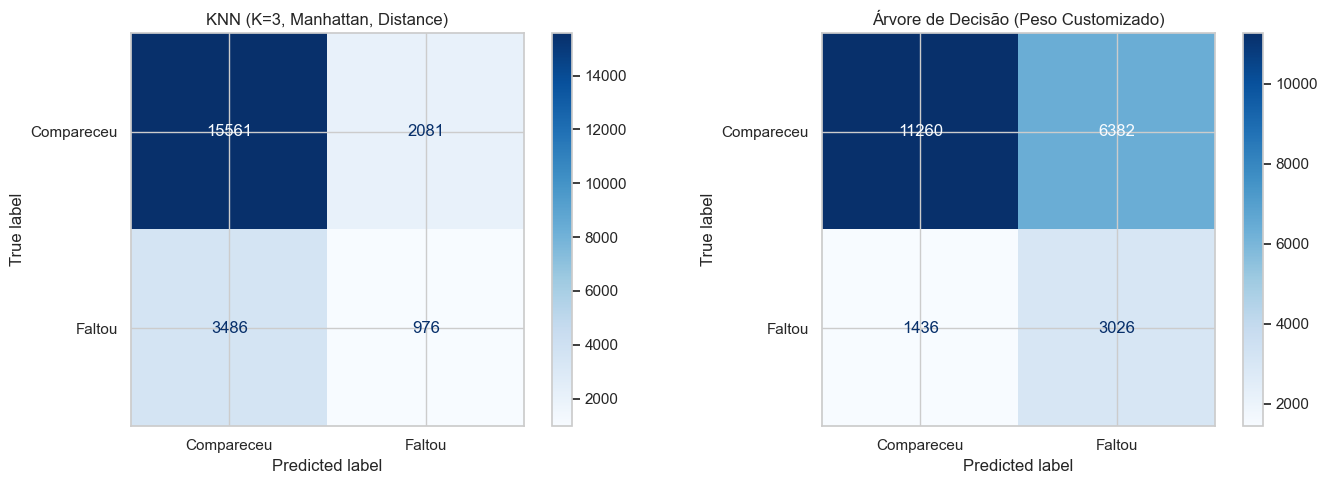

In [177]:
def comparar_modelos(X_train, X_val, X_test, y_train, y_val, y_test, preprocessor):
    print("--- KNN vs Árvore de Decisão (Conjunto de Teste) ---\n")

    modelos = {
        'KNN (K=3, Manhattan, Distance)': Pipeline([
            ('pre', preprocessor),
            ('clf', KNeighborsClassifier(**MELHOR_KNN))
        ]),
        'Árvore de Decisão (Peso Customizado)': Pipeline([
            ('pre', preprocessor),
            ('clf', DecisionTreeClassifier(max_depth=5, class_weight={0: 1, 1: 3}, random_state=42))
        ]),
    }

    resultados = []
    pipelines_treinados = {}

    for nome, pipe in modelos.items():
        t0 = time.time()
        pipe.fit(X_train, y_train)
        t_fit = time.time() - t0

        y_pred = pipe.predict(X_test)
        prec, rec, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average=None, zero_division=0)
        acc = accuracy_score(y_test, y_pred)

        resultados.append({
            'Modelo'           : nome,
            'Acurácia'         : acc,
            'F1_Compareceu'    : f1[0],
            'Recall_Compareceu': rec[0],
            'Prec_Compareceu'  : prec[0],
            'F1_Faltou'        : f1[1],
            'Recall_Faltou'    : rec[1],
            'Prec_Faltou'      : prec[1],
            'Tempo_Treino'     : round(t_fit, 4),
        })
        pipelines_treinados[nome] = (pipe, y_pred)

    df_comp = pd.DataFrame(resultados).set_index('Modelo')
    pd.options.display.float_format = '{:.3f}'.format
    display(df_comp)

    # Matrizes de confusão lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (nome, (pipe, y_pred)) in zip(axes, pipelines_treinados.items()):
        cm = confusion_matrix(y_test, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=['Compareceu', 'Faltou']).plot(ax=ax, cmap='Blues')
        ax.set_title(nome)
    plt.tight_layout()
    plt.show()

    return df_comp, pipelines_treinados

pre_escolhido = preprocessors['Esquema A - StandardScaler']
df_comparacao, pipelines = comparar_modelos(
    X_train, X_val, X_test, y_train, y_val, y_test, pre_escolhido)

### KNN vs Árvore de Decisão — Conjunto de Teste

| | KNN (K=3, Manhattan, Distance) | Árvore de Decisão (Balanced) |
| :--- | :--- | :--- |
| **Acurácia** | **0.748** | 0.553 |
| **F1 Faltou** | 0.260 | **0.439** |
| **Recall Faltou** | 0.219 | **0.868** |
| **Prec Faltou** | 0.319 | 0.294 |
| **Tempo de treino** | 0.057s | **0.042s** |

**Perfil dos erros:**

* **KNN:** erra principalmente por omissão — detecta apenas 21,9% dos faltosos.
Para cada 10 pacientes que vão faltar, o modelo avisa o hospital sobre apenas 2.
* **Árvore:** erra principalmente por excesso — gera mais alarmes falsos (Precisão
0.294), mas detecta 86,8% dos faltosos. Para cada 10 que vão faltar, o modelo
acerta 8 ou 9.

**O KNN é uma boa escolha para esta base?**

Não. Três razões:

1. **Desbalanceamento:** com 80% de comparecimentos, a vizinhança do KNN é dominada
pela classe majoritária. Mesmo com K=3 e ponderação por distância, o modelo
ignora 78% dos faltosos.
2. **Escala e sensibilidade:** o KNN exige padronização cuidadosa e é muito sensível
à remoção de atributos — onde o F1 caiu 42% sem `Waiting_Days`.
3. **Custo-benefício:** a Árvore de Decisão treina mais rápido, detecta 4x mais
faltosos e ainda oferece interpretabilidade das regras de decisão — algo que o KNN
não fornece.

---

# Questão 10

In [198]:
from sklearn.metrics import f1_score

def encontrar_threshold(pipe, X_val, y_val):
    probs = pipe.predict_proba(X_val)[:, 1]
    melhor_f1, melhor_threshold = 0, 0.5
    for t in np.arange(0.2, 0.8, 0.01):
        y_pred_t = (probs >= t).astype(int)
        f1 = f1_score(y_val, y_pred_t, zero_division=0)
        if f1 > melhor_f1:
            melhor_f1 = f1
            melhor_threshold = t
    print(f"Melhor threshold: {melhor_threshold:.2f} | F1_Faltou na validação: {melhor_f1:.3f}")
    return melhor_threshold

# Retreina a árvore e encontra o threshold ideal na validação
modelo_final = pipelines['Árvore de Decisão (Peso Customizado)'][0]
threshold_final = encontrar_threshold(modelo_final, X_val, y_val)

def predizer_noshow(novo_caso, modelo, atributos, threshold):
    if isinstance(novo_caso, dict):
        df_novo = pd.DataFrame([novo_caso])
    else:
        df_novo = novo_caso.copy()

    df_novo = df_novo[atributos]

    prob_falta = modelo.predict_proba(df_novo)[0][1]
    previsao   = int(prob_falta >= threshold)

    if previsao == 1:
        resultado    = "FALTA PROVÁVEL"
        recomendacao = "Ligar para o paciente confirmar presença."
    else:
        resultado    = "COMPARECIMENTO PROVÁVEL"
        recomendacao = "Enviar lembrete automático por SMS."

    print(f"Probabilidade de falta : {prob_falta*100:.1f}%")
    print(f"Threshold utilizado    : {threshold:.2f}")
    print(f"Previsão               : {resultado}")
    print(f"Recomendação           : {recomendacao}")

exemplo = {
    'Age'              : 28,
    'Scholarship'      : 1,
    'SMS_received'     : 0,
    'Waiting_Days'     : 15,
    'Comorbidity_Index': 0,
}

print("--- Sistema de Apoio à Decisão ---\n")
predizer_noshow(exemplo, modelo_final, ATRIBUTOS, threshold=threshold_final)

Melhor threshold: 0.46 | F1_Faltou na validação: 0.440
--- Sistema de Apoio à Decisão ---

Probabilidade de falta : 65.6%
Threshold utilizado    : 0.46
Previsão               : FALTA PROVÁVEL
Recomendação           : Ligar para o paciente confirmar presença.


## Relatório Final

### 1. Base de Dados
**Medical Appointment No Shows** — 110.527 registros, 14 colunas.

Problema: **Classificação Binária** — prever se um paciente faltará à consulta (`No-show: Yes/No`).

---

### 2. Principais Problemas Encontrados

| Problema | Qtd. | Ação |
| :--- | :--- | :--- |
| Idades negativas | 1 | Removido |
| Idades > 110 | 5 | Removido |
| Datas retroativas | 5 | Removido |
| Crianças < 12 com `Alcoholism = 1` | 6 | Corrigido para 0 |
| `PatientId` lido como float | coluna inteira | Convertido para string |
| `Handcap` com categorias raras (2, 3, 4) | 199 registros | Binarizado (0 ou 1) |
| Bairros raros em `Neighbourhood` | múltiplos | Agrupados em `OTHER` |
| Agendamentos no mesmo segundo | 6.978 (6,3%) | Registrado — não removido |

**Impacto da limpeza:** remoção de apenas 11 registros (0,01% da base), preservando a quase totalidade dos dados.

---

### 3. Atributos Mais Relevantes

| Atributo | Origem | Correlação com No-show |
| :--- | :--- | :--- |
| `Waiting_Days` | Criado (Q6) | **0.186** |
| `SMS_received` | Original | 0.126 |
| `Age` | Original | -0.060 |
| `Comorbidity_Index` | Criado (Q6) | -0.030 |
| `Scholarship` | Original | 0.029 |

`Waiting_Days` foi o atributo mais determinante — validado na Q9, onde sua remoção
derrubou o F1_Faltou em 42%.

---

### 4. Melhor Configuração do Modelo

**Modelo:** Árvore de Decisão com `class_weight={0: 1, 1: 3}` e `max_depth=5`.

**Pré-processamento (StandardScaler):**
- Numéricas (`Age`, `Waiting_Days`, `Comorbidity_Index`): imputer (mediana) + StandardScaler
- Binárias (`Scholarship`, `SMS_received`): apenas imputer (mais frequente)

**Threshold de decisão:** ajustado via busca em validação para maximizar F1_Faltou,
evitando o comportamento de *coin flip* do threshold fixo em 0.5.

---

### 5. Métricas Finais (Conjunto de Teste)

| Métrica | KNN (K=3, Manhattan, Distance) | **Árvore de Decisão** |
| :--- | :--- | :--- |
| Acurácia | 0.748 | 0.553 |
| F1 Compareceu | 0.851 | 0.677 |
| Recall Compareceu | 0.855 | 0.527 |
| F1 Faltou | 0.260 | **0.439** |
| Recall Faltou | 0.219 | **0.868** |
| Prec Faltou | 0.319 | 0.294 |
| Tempo de treino | 0.057s | **0.042s** |

---

### 6. Recomendação Executiva

Utilizar a Árvore de Decisão para filtrar diariamente os agendamentos e
contatar prioritariamente os classificados como **"Falta Provável"**.

Com Recall de 86,8%, o sistema avisa o hospital sobre 9 em cada 10 faltas
antes que aconteçam, permitindo realocar consultas e reduzir ociosidade médica.
O esforço de ligações deve ser concentrado nos casos sinalizados — não em toda
a agenda.

---

### 7. Avaliação Crítica — Maturidade da Solução

**Nível atual: Piloto.**

O fluxo está automatizado, reproduzível e reaplicável a novos dados sem
vazamento de informação. A função `predizer_noshow` permite integração direta
com sistemas de agendamento.

**Limitações:**

* **Precisão baixa (0.294):** 7 em cada 10 alarmes são falsos positivos.
O hospital ligará para pacientes que compareceriam normalmente, gerando
custo operacional desnecessário.
* **Ausência de histórico individual:** o preditor mais direto disponível —
quantas vezes o paciente já faltou — não está na base. Incluí-lo seria a
melhoria de maior impacto.
* **Dados de 2016:** comportamento de absenteísmo pode ter mudado, especialmente
após a pandemia. O modelo precisa ser retreinado com dados recentes antes de
qualquer implantação.
* **Threshold fixo por validação:** o threshold ótimo foi encontrado em dados
de 2016 e pode não generalizar bem em produção. O ideal é reavaliá-lo
periodicamente.

**Para evoluir para produção:**
1. Adicionar histórico de faltas anteriores por `PatientId`.
2. Retreinar trimestralmente com dados recentes.
3. Monitorar a taxa de falsos positivos operacionalmente e ajustar o threshold
conforme a capacidade da equipe de realizar ligações.